# Problem Set 2
## Time Series, Discretization, and Markov Chains


In [2]:
import sys
!{sys.executable} -m pip install fredapi

## Problem 1: Weekly Economic Index

Import the **Weekly Economic Index (WEI)** from FRED.

- Plot the series.
- Store the data in a Pandas DataFrame.
- Clearly label axes and include a title.


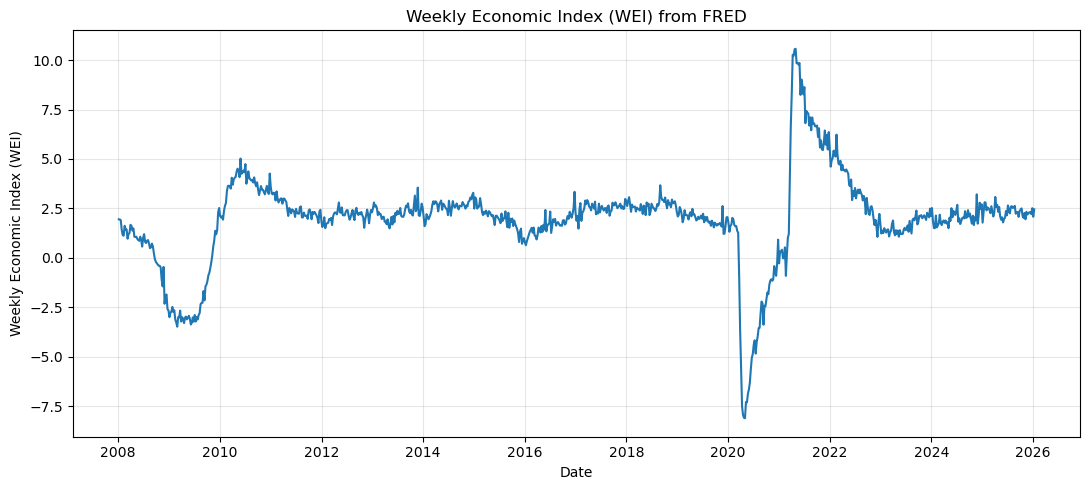

,WEI
date,
2008-01-05,1.95
2008-01-12,1.94
2008-01-19,1.91
2008-01-26,1.42
2008-02-02,1.15


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred

fred = Fred(api_key="021ea6c1be7ea16dff888f17361fd868")  

wei = fred.get_series("WEI")               # downloads the time series
df_wei = wei.to_frame(name="WEI")          # store as DataFrame
df_wei.index.name = "date"

plt.figure(figsize=(11,5))
plt.plot(df_wei.index, df_wei["WEI"])
plt.xlabel("Date")
plt.ylabel("Weekly Economic Index (WEI)")
plt.title("Weekly Economic Index (WEI) from FRED")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

df_wei.head()


## Problem 2: Stationarity and Linear Time-Series Analysis

(a) Use the **Augmented Dickey–Fuller (ADF)** test to determine whether the series is stationary.

(b) Plot the **partial autocorrelation function (PACF)** out to 25 lags.

(c) Estimate an **AR(1)** model and report the coefficient on the lagged endogenous variable.


### Problem 2(a)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.ar_model import AutoReg

y = df_wei["WEI"].dropna()
result = adfuller(y, autolag="AIC")  # common default choice
adf_stat, pval, usedlag, nobs, crit_vals, icbest = result

print("ADF statistic:", adf_stat)
print("p-value:", pval)
print("Used lags:", usedlag)
print("N obs:", nobs)
print("Critical values:", crit_vals)

if pval < 0.05:
    print("Conclusion: Reject H0 at 5% → evidence WEI is stationary.")
else:
    print("Conclusion: Fail to reject H0 at 5% → evidence WEI signals non-stationarity.")


ADF statistic: -3.724273360039838
p-value: 0.003784396884214647
Used lags: 6
N obs: 934
Critical values: {'1%': np.float64(-3.4373707314972766), '5%': np.float64(-2.8646394422797337), '10%': np.float64(-2.5684203292233905)}
Conclusion: Reject H0 at 5% → evidence WEI is stationary.


**ADF = −3.724 with p = 0.0038, so we reject the unit-root null at 5% and conclude WEI is stationary.**

### Problem 2(b)

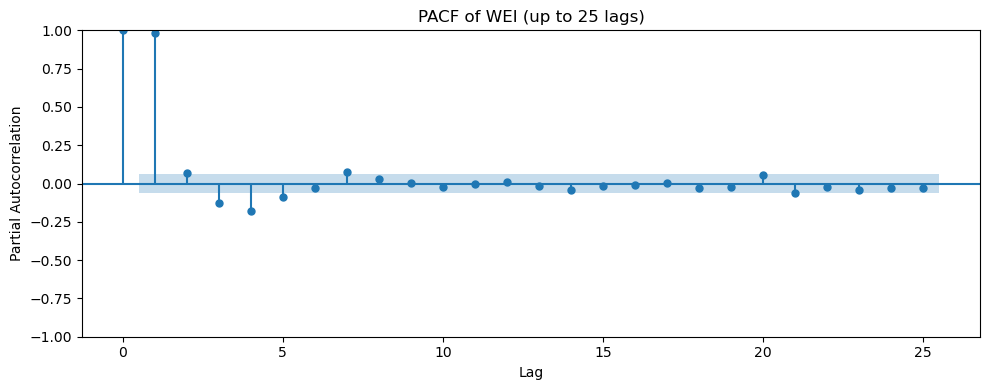

In [4]:
fig, ax = plt.subplots(figsize=(10,4))
plot_pacf(y, lags=25, ax=ax, method="ywm")
ax.set_title("PACF of WEI (up to 25 lags)")
ax.set_xlabel("Lag")
ax.set_ylabel("Partial Autocorrelation")
plt.tight_layout()
plt.show()


### Probelm 2(c)

In [5]:
ar1 = AutoReg(y, lags=1, trend="c", old_names=False).fit()
print(ar1.summary())

phi = ar1.params["WEI.L1"]  # coefficient on lagged WEI
print("\nAR(1) coefficient (phi) on WEI_{t-1}:", phi)

                            AutoReg Model Results                             
Dep. Variable:                    WEI   No. Observations:                  941
Model:                     AutoReg(1)   Log Likelihood                -517.410
Method:               Conditional MLE   S.D. of innovations              0.420
Date:                Fri, 16 Jan 2026   AIC                           1040.820
Time:                        13:42:15   BIC                           1055.357
Sample:                    01-12-2008   HQIC                          1046.362
                         - 01-10-2026                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0362      0.018      1.975      0.048       0.000       0.072
WEI.L1         0.9819      0.006    158.689      0.000       0.970       0.994
                                    Roots           

C:\Users\patrick\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)


**Estimating an AR(1) gives 𝜙≈0.982, indicating strong persistence: changes to WEI carry over heavily from one week to the next. Because 𝜙
ϕ is close to 1, shocks dissipate slowly, so the series exhibits long memory even though the ADF test rejects a unit root.**

## Problem 3: Distributional Properties

Plot a histogram of the Weekly Economic Index and return the counts, bins, and patches.


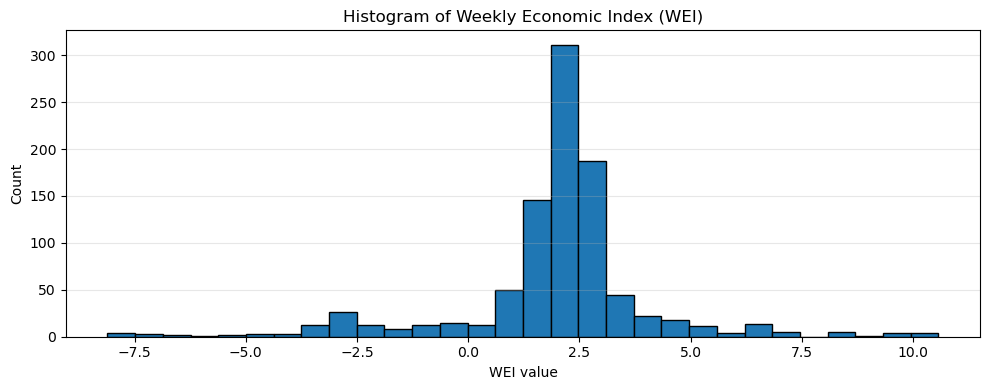

Counts: [  4.   3.   2.   1.   2.   3.   3.  12.  26.  12.   8.  12.  15.  12.
  50. 146. 311. 187.  44.  22.  18.  11.   4.  14.   5.   0.   5.   1.
   4.   4.]

Bin edges: [-8.11       -7.48733333 -6.86466667 -6.242      -5.61933333 -4.99666667
 -4.374      -3.75133333 -3.12866667 -2.506      -1.88333333 -1.26066667
 -0.638      -0.01533333  0.60733333  1.23        1.85266667  2.47533333
  3.098       3.72066667  4.34333333  4.966       5.58866667  6.21133333
  6.834       7.45666667  8.07933333  8.702       9.32466667  9.94733333
 10.57      ]

Number of patches: 30


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Use the same series you already defined
y = df_wei["WEI"].dropna()

# Histogram
fig, ax = plt.subplots(figsize=(10,4))
counts, bins, patches = ax.hist(y, bins=30, edgecolor="black")  # you can change 30 if you want

ax.set_title("Histogram of Weekly Economic Index (WEI)")
ax.set_xlabel("WEI value")
ax.set_ylabel("Count")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Show the returned objects
counts, bins, patches
print("Counts:", counts)
print("\nBin edges:", bins)
print("\nNumber of patches:", len(patches))


## Problem 4: Discretization into States

Classify the data into discrete states using histogram bins.

```python
def classify(x, bins, states):
    n = len(bins)
    conditions = []
    for i in range(n - 1):
        conditions.append((x <= bins[i+1]) & (x >= bins[i]))
    return np.select(conditions, states)
```


In [11]:
def classify(x, bins, states):
    n = len(bins)
    conditions = []
    
    # bins 0..n-2: [bins[i], bins[i+1])  (right-open)
    for i in range(n - 2):
        conditions.append((x >= bins[i]) & (x < bins[i+1]))
        
    # last bin: [bins[n-2], bins[n-1]] (include max)
    conditions.append((x >= bins[n-2]) & (x <= bins[n-1]))
    
    return np.select(conditions, states, default=np.nan)

y = df_wei["WEI"].dropna().to_numpy()
state_labels = np.arange(len(bins) - 1)           # 0..29 if 30 bins
wei_states = classify(y, bins, state_labels).astype(int)

wei_states[:10], wei_states.min(), wei_states.max()
df_states = df_wei.dropna().copy()
df_states["state"] = wei_states
df_states.head()


,WEI,state
date,,
2008-01-05,1.95,16
2008-01-12,1.94,16
2008-01-19,1.91,16
2008-01-26,1.42,15
2008-02-02,1.15,14


## Problem 5: State-Dependent Means

Group the data by state and compute the mean within each state.


In [13]:
# df_states has columns: WEI and state (from Problem 4)
state_means = df_states.groupby("state")["WEI"].mean()

state_means.head(), state_means.tail()

(state
 0   -7.917500
 1   -7.156667
 2   -6.485000
 3   -5.620000
 4   -5.285000
 Name: WEI, dtype: float64,
 state
 24     7.2540
 26     8.4200
 27     9.0200
 28     9.8300
 29    10.4025
 Name: WEI, dtype: float64)

**When I group WEI by the state (the bin it falls into) and take the average within each state, the averages rise as the state number rises. The lowest states capture those rare weeks where WEI is extremely negative (for example, state 0 averages about −7.92), while the highest states capture rare weeks where WEI is extremely positive (for example, state 29 averages about 10.40). Overall, this shows the discretization worked the way we wanted: bigger state numbers line up with stronger economic conditions.**

## Problem 6: Estimation of the Markov Transition Matrix

Estimate the Markov transition matrix.


In [21]:
import numpy as np
import pandas as pd

s = df_states["state"].to_numpy()
K = int(s.max() + 1)  # number of states (should be 30)

# Count transitions
counts = np.zeros((K, K), dtype=int)
for t in range(len(s) - 1):
    i = int(s[t])
    j = int(s[t + 1])
    counts[i, j] += 1

# Convert counts -> probabilities (row-normalize)
row_sums = counts.sum(axis=1, keepdims=True)
# P = counts / row_sums  # each row i sums to 1

P = np.divide(
    counts, row_sums,
    out=np.zeros_like(counts, dtype=float),
    where=row_sums != 0
)
P_df = pd.DataFrame(P, index=[f"s{i}" for i in range(K)], columns=[f"s{j}" for j in range(K)])

# Sanity checks
print("K =", K)
print("Row sums (should be 1):", np.round(P.sum(axis=1), 6)[:10])
P_df.iloc[:5, :5]

K = 30
Row sums (should be 1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


,s0,s1,s2,s3,s4
s0,0.75,0.250000,0.000000,0.0,0.0
s1,0.00,0.666667,0.333333,0.0,0.0
s2,0.00,0.000000,0.500000,0.5,0.0
s3,0.00,0.000000,0.000000,0.0,1.0
s4,0.50,0.000000,0.000000,0.0,0.0


## Problem 7: Properties of the Markov Chain

Check irreducibility, aperiodicity, and communication classes.


In [22]:
import numpy as np
from collections import deque
from math import gcd

P = P_df.to_numpy()  # if you have P_df; otherwise if you have P already, skip this line
K = P.shape[0]
A = (P > 0).astype(int)  # adjacency: 1 if transition possible

def reachability_matrix(A):
    K = A.shape[0]
    R = np.zeros((K, K), dtype=bool)
    for s in range(K):
        seen = np.zeros(K, dtype=bool)
        q = deque([s])
        seen[s] = True
        while q:
            u = q.popleft()
            for v in np.where(A[u] == 1)[0]:
                if not seen[v]:
                    seen[v] = True
                    q.append(v)
        R[s] = seen
    return R

R = reachability_matrix(A)

# communicate[i,j] True iff i reaches j and j reaches i
communicate = R & R.T

# Extract classes by grouping mutual-communication sets
unassigned = set(range(K))
classes = []

while unassigned:
    i = next(iter(unassigned))
    cls = set(np.where(communicate[i])[0])  # all that communicate with i
    classes.append(sorted(cls))
    unassigned -= cls

classes
print("Number of communication classes:", len(classes))
for idx, cls in enumerate(classes, 1):
    print(f"Class {idx} (size {len(cls)}):", cls)

# irreducibility
is_irreducible = (len(classes) == 1 and len(classes[0]) == K)
print("Irreducible?", is_irreducible)

# Aperiodicity for each class
def class_is_aperiodic(P, cls):
    cls = np.array(cls, dtype=int)
    # If any state has P_ii > 0, the class is aperiodic
    for i in cls:
        if P[i, i] > 0:
            return True
    return False

for idx, cls in enumerate(classes, 1):
    print(f"Class {idx} aperiodic (self-loop test)?", class_is_aperiodic(P, cls))


Number of communication classes: 2
Class 1 (size 29): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(26), np.int64(27), np.int64(28), np.int64(29)]
Class 2 (size 1): [np.int64(25)]
Irreducible? False
Class 1 aperiodic (self-loop test)? True
Class 2 aperiodic (self-loop test)? False


**Overall, the estimated WEI Markov chain behaves like one large, well-connected, aperiodic component (Class 1), plus one isolated state (Class 2). The isolated state is most likely an artifact of discretization and limited data in that bin (rare state), rather than a meaningful “separate regime” of the economy. Due  to the fact that there is more than one communication class, the chain is not irreducible (reducible). Intuitively, state 25 does not “communicate” with the other states. So, either the data never shows transitions into/out of it in both directions, or it is effectively isolated due to very few observations in that bin.**

## Problem 8: Ergodic Distribution

Find and interpret the ergodic distribution.


Check: sum(pi) over Class 1 = 0.9999999999999999
Check: sum(pi_full) over all 30 states = 0.9999999999999999

Top 10 states by ergodic probability (Class 1):


,state,pi
16,16,0.329787
17,17,0.198936
15,15,0.155319
14,14,0.053191
18,18,0.046809
8,8,0.027660
19,19,0.023404
20,20,0.019149
12,12,0.015957
23,23,0.014894


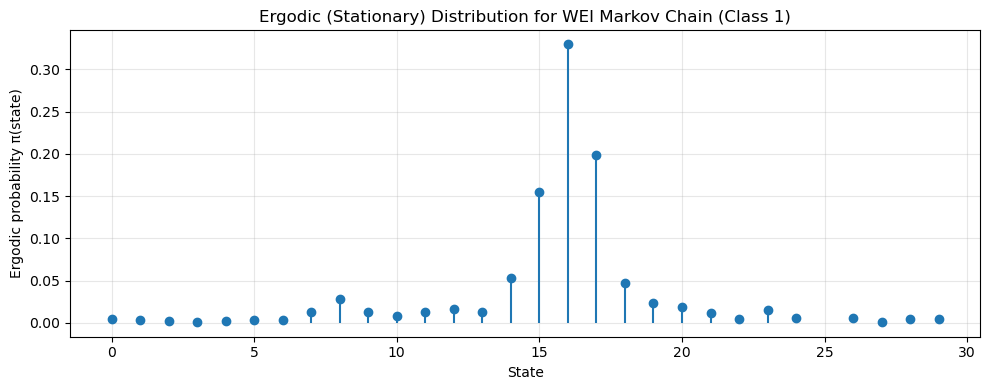

In [24]:
# =========================
# Problem 8: Ergodic (Stationary) Distribution
# =========================
# Goal:
#   Find the long-run (steady-state) probabilities pi over the Markov chain states.
#
# Key idea:
#   Stationary distribution pi satisfies:  pi = pi P  and  sum(pi)=1.
#
# Important note for YOUR case:
#   Your chain is REDUCIBLE (2 communication classes), so there is not a single unique
#   stationary distribution that mixes across all 30 states. The meaningful "ergodic"
#   distribution is computed on the large recurrent class (Class 1). We can also embed
#   it into a length-30 vector with zero mass on the isolated state (25).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Get the numeric transition matrix P (KxK) ---
P = P_df.to_numpy()
K = P.shape[0]

# --- 2) Define the main communication class (Class 1) from your Problem 7 output ---
class1 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
          20, 21, 22, 23, 24, 26, 27, 28, 29]

# --- 3) Restrict P to Class 1 only ---
P1 = P[np.ix_(class1, class1)]

# --- 4) Compute stationary distribution on Class 1 ---
# Stationary pi is the eigenvector of P1.T associated with eigenvalue 1
eigvals, eigvecs = np.linalg.eig(P1.T)
idx = np.argmin(np.abs(eigvals - 1))
pi = np.real(eigvecs[:, idx])

# Normalize and clean numerical noise
pi = pi / pi.sum()
pi = np.maximum(pi, 0)
pi = pi / pi.sum()

# Put into a DataFrame for readability
pi_df = pd.DataFrame({"state": class1, "pi": pi}).sort_values("state").reset_index(drop=True)
print("Check: sum(pi) over Class 1 =", pi_df["pi"].sum())

# --- 5) Optional: embed into full length-30 vector with pi(25)=0 ---
pi_full = np.zeros(K)
pi_full[class1] = pi
print("Check: sum(pi_full) over all 30 states =", pi_full.sum())

# --- 6) Show the most common states in the long run ---
top10 = pi_df.sort_values("pi", ascending=False).head(10)
print("\nTop 10 states by ergodic probability (Class 1):")
display(top10)

# --- 7) Plot the ergodic distribution over Class 1 ---
plt.figure(figsize=(10,4))
plt.stem(pi_df["state"], pi_df["pi"], basefmt=" ")
plt.xlabel("State")
plt.ylabel("Ergodic probability π(state)")
plt.title("Ergodic (Stationary) Distribution for WEI Markov Chain (Class 1)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Because the estimated Markov chain is **reducible** (Problem 7 identified two communication classes), there is not a single unique ergodic distribution that mixes across all 30 states. Instead, the relevant long-run behavior is described by the stationary (ergodic) distribution on the main, aperiodic communication class (Class 1). We compute the ergodic distribution $\pi$ on this class as the stationary probability vector satisfying
$\pi = \pi P, \qquad \sum_i \pi_i = 1,$
where P is the estimated transition matrix restricted to Class 1.

The computed ergodic distribution is highly concentrated in the middle states. The most likely long-run states are
$
\pi_{16} \approx 0.3298, \qquad 
\pi_{17} \approx 0.1989, \qquad 
\pi_{15} \approx 0.1553.
$

In particular, the combined long-run probability of being in states $15$--$17$ is approximately
$
\pi_{15} + \pi_{16} + \pi_{17}
\approx 0.1553 + 0.3298 + 0.1989
\approx 0.684,
$
so the chain spends about $68\%$ of the time in these ``typical'' mid-range WEI bins. By contrast, the extreme low and high states have much smaller ergodic probabilities, meaning they occur relatively rarely in the long run. Interpreting $\pi_i$ as a time share, $\pi_i$ represents the approximate fraction of weeks the discretized WEI process spends in state $i$ when the chain evolves for a long time within the main class.


## Problem 9: Simulation from the Current State

Simulate the process forward for two years from the current state.


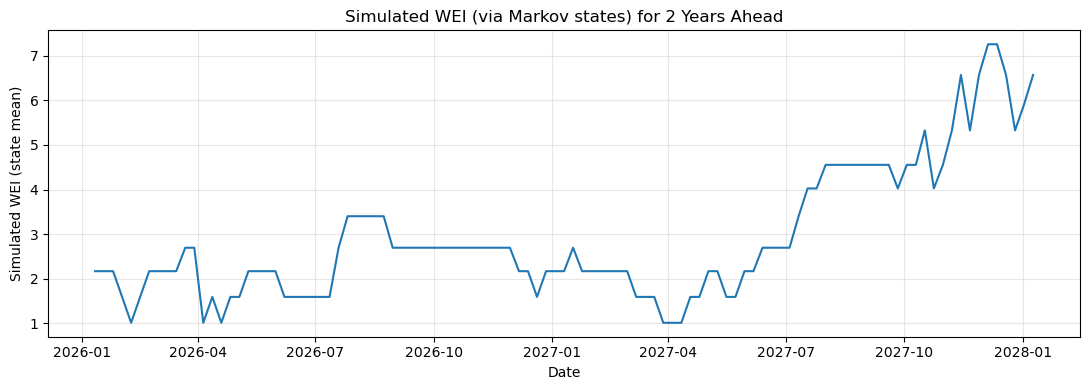

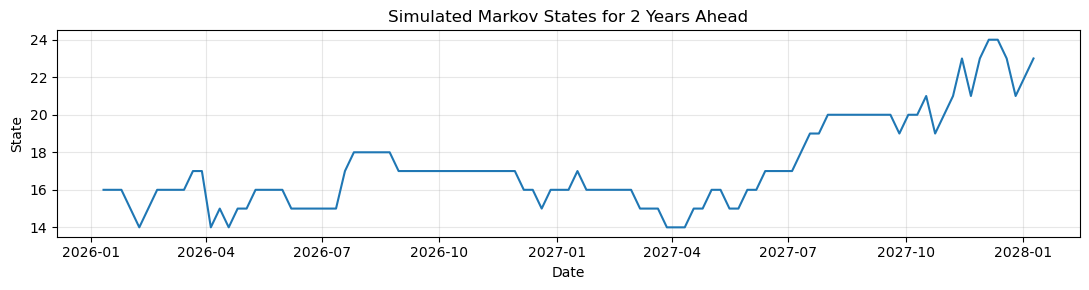

,state,WEI_sim
date,,
2026-01-11,16,2.170611
2026-01-18,16,2.170611
2026-01-25,16,2.170611
2026-02-01,15,1.594452
2026-02-08,14,1.014600


In [26]:
# =========================
# Problem 9: Simulate forward 2 years from the current state
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Inputs you already have from earlier problems ---
# df_states: DataFrame with columns ["WEI", "state"] indexed by date
# P_df: transition matrix DataFrame (KxK)
# state_means: Series mapping state -> mean WEI within that state (Problem 5)

# 1) Basic objects
P = P_df.to_numpy()
K = P.shape[0]

# 2) Current (most recent) state from the data
s0 = int(df_states["state"].iloc[-1])

# 3) Simulation horizon: 2 years of weekly steps
T = 104  # 2 years * 52 weeks

# 4) Simulate the state path
rng = np.random.default_rng(0)  # fixed seed for reproducibility (optional)
sim_states = np.empty(T + 1, dtype=int)
sim_states[0] = s0

for t in range(T):
    i = sim_states[t]
    probs = P[i].copy()

    # If a row is all zeros (can happen for isolated/unused states), stay put as a fallback
    if probs.sum() == 0:
        sim_states[t + 1] = i
    else:
        sim_states[t + 1] = rng.choice(np.arange(K), p=probs)

# 5) Map states -> "simulated WEI" using state-dependent means (Problem 5)
#    This turns the discrete simulation into a WEI-level path.
mu = state_means.reindex(range(K)).to_numpy()  # ensure aligned by state index
sim_wei = mu[sim_states]

# 6) Build a date index continuing weekly from the last observed date
start_date = df_states.index[-1]
sim_dates = pd.date_range(start=start_date, periods=T + 1, freq="W")

sim_df = pd.DataFrame({"state": sim_states, "WEI_sim": sim_wei}, index=sim_dates)
sim_df.index.name = "date"

# 7) Plot the simulated WEI path
plt.figure(figsize=(11,4))
plt.plot(sim_df.index, sim_df["WEI_sim"])
plt.title("Simulated WEI (via Markov states) for 2 Years Ahead")
plt.xlabel("Date")
plt.ylabel("Simulated WEI (state mean)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8) Also show the simulated states (optional)
plt.figure(figsize=(11,3))
plt.plot(sim_df.index, sim_df["state"])
plt.title("Simulated Markov States for 2 Years Ahead")
plt.xlabel("Date")
plt.ylabel("State")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Output: first few simulated rows
sim_df.head()


Starting from the most recent observed state (state 16), I simulated the discretized WEI Markov chain forward 104 weeks (two years). The simulated state path shows strong persistence, with most week-to-week movements occurring between neighboring states. Mapping states to WEI values using state-dependent means produces a WEI simulation that stays near typical mid-range values early in the horizon and later drifts into higher states, illustrating how the estimated transition matrix can generate persistent periods and gradual shifts over time.

## Problem 10: Mean Hitting Times

Compute the mean hitting time of the worst state.


In [27]:
import numpy as np
import pandas as pd

# --- Inputs you already have ---
# P_df: transition matrix (KxK)
# state_means: mean WEI within each state (Problem 5)
# df_states: has last observed state if you want "from current state"
P = P_df.to_numpy()
K = P.shape[0]

# 1) Identify the "worst" state = state with smallest state-dependent mean
# (This should be 0, but we compute it programmatically)
worst_state = int(state_means.idxmin())
print("Worst state (lowest mean WEI):", worst_state, "with mean WEI =", state_means.loc[worst_state])

# 2) Define the main communication class from Problem 7 (ergodic class)
class1 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
          20, 21, 22, 23, 24, 26, 27, 28, 29]

# Make sure worst_state is in class1
assert worst_state in class1, "Worst state is not in the main class; adjust target/class."

# 3) Work on the submatrix for Class 1 only
idx_map = {s:i for i,s in enumerate(class1)}         # map original state -> submatrix index
P1 = P[np.ix_(class1, class1)]
w = idx_map[worst_state]                              # target index in submatrix
m = len(class1)

# 4) Build linear system for hitting times h (size m)
# For i != w: h_i - sum_j P_ij h_j = 1
# For i == w: h_w = 0
A = np.eye(m)
b = np.ones(m)

for i in range(m):
    if i == w:
        A[i, :] = 0
        A[i, i] = 1
        b[i] = 0
    else:
        A[i, :] -= P1[i, :]

h = np.linalg.solve(A, b)  # expected hitting times (in weeks) to hit worst_state

# 5) Put results back into original state labels
h_df = pd.DataFrame({"state": class1, "mean_hitting_time_to_worst": h}).sort_values("state")
display(h_df.head(10))

# 6) Answer they probably want: mean hitting time from the CURRENT state
current_state = int(df_states["state"].iloc[-1])
if current_state in idx_map:
    print("\nMean hitting time (weeks) from CURRENT state", current_state, "to worst state", worst_state, "=", h[idx_map[current_state]])
else:
    print("\nCurrent state is not in Class 1 (rare).")

# 7) If they literally mean “worst starting state” (largest expected time to reach the worst state)
worst_start_idx = int(np.argmax(h))
worst_start_state = class1[worst_start_idx]
print("\nState with the LARGEST mean hitting time to worst state:", worst_start_state,
      "with E[tau] =", h[worst_start_idx], "weeks")


Worst state (lowest mean WEI): 0 with mean WEI = -7.9174999999999995


,state,mean_hitting_time_to_worst
0,0,0.000000
1,1,936.000000
2,2,933.000000
3,3,931.000000
4,4,930.000000
5,5,1858.000000
6,6,1856.500000
7,7,1852.000000
8,8,1943.866667
9,9,2118.933333



Mean hitting time (weeks) from CURRENT state 16 to worst state 0 = 2667.782856018486

State with the LARGEST mean hitting time to worst state: 29 with E[tau] = 2739.4929715418607 weeks


I define the worst state as the discretized state with the lowest state-dependent mean of the Weekly Economic Index (WEI). Using the state means from Problem 5, the worst state is
$
w = 0, \qquad \bar{y}_0 \approx -7.9175.
$ (computed in Problem 5)
Let $h_i$ denote the mean hitting time (in weeks) to reach state $w$ starting from state $i$, i.e.
$
h_i = \mathbb{E}_i[\tau_w], \qquad \tau_w = \inf\{t \ge 0: s_t = w\}.
$
The mean hitting times satisfy the standard linear system
$
h_w = 0, \qquad 
h_i = 1 + \sum_{j} P_{ij} h_j \quad \text{for } i \neq w,
$
where $P$ is the estimated Markov transition matrix (restricted to the main communication class).

Solving this system yields a mean hitting time from the current state (state $16$) to the worst state (state $0$) of
$
h_{16} \approx 2667.78 \text{ weeks}.
$
The state with the largest mean hitting time to the worst state is state $29$, with
$
\max_i h_i = h_{29} \approx 2739.49 \text{ weeks}.
$
These large values imply that entering the worst WEI state is a very rare event under the estimated transition dynamics.


## Problem 11: Probability of Extreme Events

Compute the probability of entering a Covid-like state within two years.


In [28]:
import numpy as np
import pandas as pd

# Inputs you already have:
# P_df: transition matrix
# df_states: contains the current state in the last row
# state_means: mean WEI within each state (Problem 5)  [used for threshold definition]

P = P_df.to_numpy()
K = P.shape[0]

# Current state
s0 = int(df_states["state"].iloc[-1])

# Horizon: 2 years of weekly steps
T = 104

# ---------------------------
# Choose ONE definition of "Covid-like" states
# ---------------------------

# Option A (recommended): threshold on state-dependent mean WEI
# Example threshold: mean WEI <= -5 (captures extreme downturn)
threshold = -5.0
covid_states = set(state_means[state_means <= threshold].index.astype(int).tolist())

# Option B: take bottom k states (uncomment if your instructor defines it like this)
# k = 3
# covid_states = set(range(k))  # {0,1,2}

print("Covid-like states C =", sorted(covid_states))

# ---------------------------
# Dynamic programming for hitting probability within T steps
# ---------------------------
# p[i] will represent: Prob(hit C within remaining steps starting from state i)

# Base case: within 0 steps, probability is 1 if already in C, else 0
p = np.zeros(K)
for i in range(K):
    p[i] = 1.0 if i in covid_states else 0.0

# Iterate forward for t = 1..T:
# If you're in C, you already "hit" it => p stays 1.
# Otherwise p_new[i] = sum_j P[i,j] * p[j]
for _ in range(T):
    p_new = P @ p
    for i in covid_states:
        p_new[i] = 1.0
    p = p_new

prob_from_current = p[s0]
print(f"\nProbability of entering a Covid-like state within {T} weeks starting from current state {s0}:")
print(prob_from_current)


Covid-like states C = [0, 1, 2, 3, 4]

Probability of entering a Covid-like state within 104 weeks starting from current state 16:
0.041459610753943596


Define the set of ``Covid-like'' states as $C=\{0,1,2,3,4\}$. Starting from the current state $s_0=16$ and using a two-year horizon of $T=104$ weeks, we compute the finite-horizon hitting probability $\mathbb{P}(\exists\, t\in\{1,\dots,T\}\text{ such that } s_t\in C \mid s_0=16)$. Using dynamic programming under the estimated transition matrix $P$, the probability of entering a Covid-like state within two years is approximately $0.04146$ (about $4.15\%$).


## Problem 12: Model Validation via Simulation

Simulate the Markov chain and repeat the AR(1) analysis.


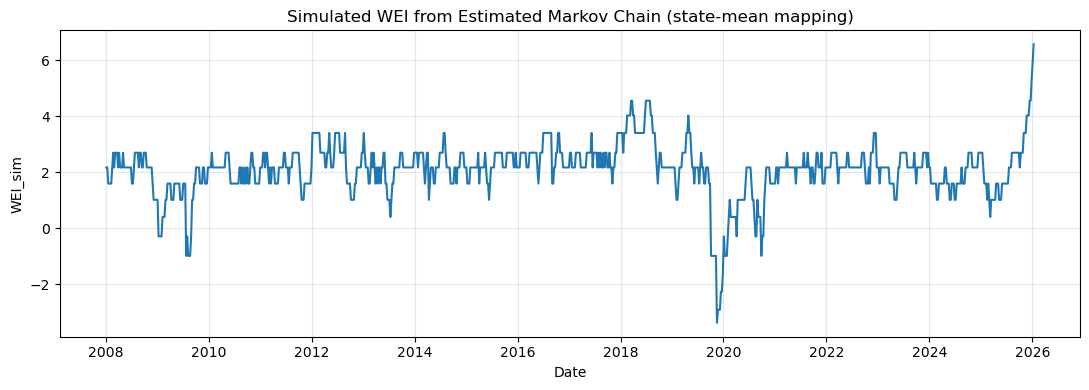

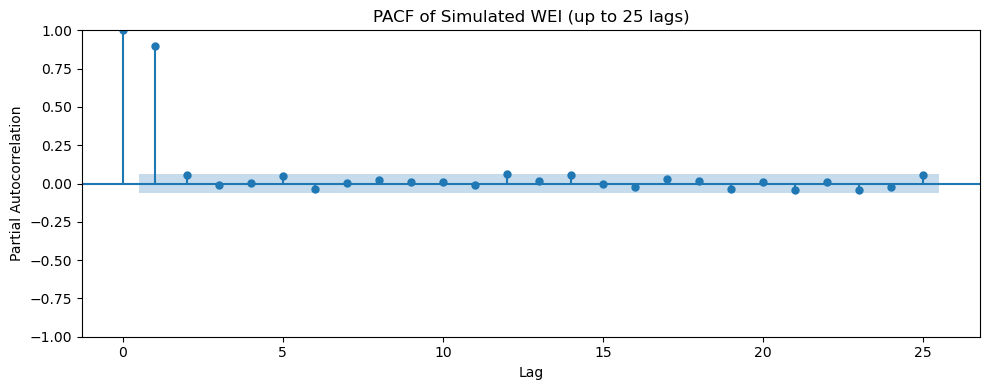

                            AutoReg Model Results                             
Dep. Variable:                WEI_sim   No. Observations:                  941
Model:                     AutoReg(1)   Log Likelihood                -467.479
Method:               Conditional MLE   S.D. of innovations              0.398
Date:                Sun, 18 Jan 2026   AIC                            940.959
Time:                        14:45:36   BIC                            955.497
Sample:                    01-12-2008   HQIC                           946.501
                         - 01-10-2026                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1725      0.032      5.465      0.000       0.111       0.234
WEI_sim.L1     0.9197      0.014     66.840      0.000       0.893       0.947
                                    Roots           

C:\Users\patrick\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
C:\Users\patrick\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)


In [29]:
# =========================
# Problem 12: Model validation via simulation
# Simulate the Markov chain and repeat the AR(1) analysis
# =========================
# Intuition:
# 1) Your estimated Markov chain generates a discrete state process s_t.
# 2) To compare with the original WEI series, we map each simulated state to a WEI value.
#    The simplest mapping (consistent with earlier problems) is: WEI_sim(t) = mean WEI in state s_t.
# 3) Once we have a simulated WEI series, we redo the AR(1) fit:
#       WEI_sim(t) = c + phi * WEI_sim(t-1) + eps_t
#    and compare phi to the phi you estimated on the real WEI.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_pacf

# -------------------------
# Inputs you already have:
#   P_df       : transition matrix (KxK)
#   df_states  : DataFrame with columns ["WEI","state"] indexed by date
#   state_means: Series mapping state -> mean(WEI | state) from Problem 5
# -------------------------

# 0) Core objects
P = P_df.to_numpy()
K = P.shape[0]

# 1) Simulation length: match the length of the observed sample (good for validation)
T = len(df_states)  # number of weekly observations you used

# 2) Starting state: use the same initial state as the real sample (or use current state)
s0 = int(df_states["state"].iloc[0])   # start-of-sample state
# s0 = int(df_states["state"].iloc[-1])  # alternatively: start from current state

# 3) Simulate the Markov state path
rng = np.random.default_rng(123)  # seed for reproducibility
sim_states = np.empty(T, dtype=int)
sim_states[0] = s0

for t in range(T - 1):
    i = sim_states[t]
    probs = P[i].copy()
    if probs.sum() == 0:
        # if a state has no observed outgoing transitions, just stay there (rare edge case)
        sim_states[t + 1] = i
    else:
        sim_states[t + 1] = rng.choice(np.arange(K), p=probs)

# 4) Map simulated states -> simulated WEI values using state-dependent means
mu = state_means.reindex(range(K)).to_numpy()
wei_sim = mu[sim_states]

# Put into a DataFrame with the same date index as the real data
sim_df = pd.DataFrame({"state_sim": sim_states, "WEI_sim": wei_sim}, index=df_states.index)
sim_df.index.name = "date"

# -------------------------
# (A) Plot simulated series (optional but helpful)
# -------------------------
plt.figure(figsize=(11,4))
plt.plot(sim_df.index, sim_df["WEI_sim"])
plt.title("Simulated WEI from Estimated Markov Chain (state-mean mapping)")
plt.xlabel("Date")
plt.ylabel("WEI_sim")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------
# (B) Repeat PACF (like Problem 2b)
# -------------------------
fig, ax = plt.subplots(figsize=(10,4))
plot_pacf(sim_df["WEI_sim"], lags=25, ax=ax, method="ywm")
ax.set_title("PACF of Simulated WEI (up to 25 lags)")
ax.set_xlabel("Lag")
ax.set_ylabel("Partial Autocorrelation")
plt.tight_layout()
plt.show()

# -------------------------
# (C) Repeat AR(1) estimation (like Problem 2c)
# -------------------------
ar1_sim = AutoReg(sim_df["WEI_sim"], lags=1, trend="c", old_names=False).fit()
print(ar1_sim.summary())

phi_sim = ar1_sim.params.get("WEI_sim.L1", np.nan)  # coefficient on lagged simulated WEI
c_sim   = ar1_sim.params.get("const", np.nan)

print("\nAR(1) on simulated WEI:")
print("  const =", c_sim)
print("  phi   =", phi_sim)

# -------------------------
# (D) Compare to the AR(1) phi from the real WEI (optional)
# -------------------------
ar1_real = AutoReg(df_states["WEI"], lags=1, trend="c", old_names=False).fit()
phi_real = ar1_real.params.get("WEI.L1", np.nan)
c_real   = ar1_real.params.get("const", np.nan)

print("\nAR(1) on real WEI:")
print("  const =", c_real)
print("  phi   =", phi_real)

print("\nComparison:")
print("  phi_sim  =", phi_sim)
print("  phi_real =", phi_real)
print("  difference (sim - real) =", phi_sim - phi_real)


In this validation step, I simulated a synthetic WEI time series by (i) simulating a Markov state path $\{s_t\}$ from the estimated transition matrix $P$ (starting from the sample’s initial state), and then (ii) mapping each simulated state to a WEI value using the state-dependent mean, i.e., $\mathrm{WEI}^{\text{sim}}_t=\bar{y}_{s_t}$. I then repeated the same time-series diagnostics on $\mathrm{WEI}^{\text{sim}}_t$ as in Problem 2: I plotted the PACF (which shows a dominant first-lag effect) and estimated an AR(1) model $\mathrm{WEI}^{\text{sim}}_t=c+\phi\,\mathrm{WEI}^{\text{sim}}_{t-1}+\varepsilon_t$. The AR(1) fit on the simulated series gives $\hat{\phi}_{\text{sim}}\approx 0.9197$ (with $\hat{c}_{\text{sim}}\approx 0.1725$), while the AR(1) fit on the real WEI gives $\hat{\phi}_{\text{real}}\approx 0.9819$ (with $\hat{c}_{\text{real}}\approx 0.0362$), so $\hat{\phi}_{\text{sim}}-\hat{\phi}_{\text{real}}\approx -0.0621$. This indicates the simulated Markov-based series is still highly persistent ($\phi$ close to 1), but it is \emph{less} persistent than the real WEI; in other words, the discretized Markov model understates th


## Problem 13: Persistence, Mixing, and Long-Run Forecasts

Analyze persistence, expected duration, mixing time, and forecasting.  Please use the total variation distance starting from the current state to describe mixing time.  Forecast the expected growth rate of GDP using the state means and the ergodic distribution of the Markov process.


Current state = 16

Expected duration (weeks) by state (first 10):


,state,P_ii,E_duration_weeks
0,0,0.750000,4.000000
1,1,0.666667,3.000000
2,2,0.500000,2.000000
3,3,0.000000,1.000000
4,4,0.000000,1.000000
5,5,0.333333,1.500000
6,6,0.333333,1.500000
7,7,0.250000,1.333333
8,8,0.653846,2.888889
9,9,0.500000,2.000000



Expected duration in CURRENT state: 3.0693069306930694 weeks

Check sum(pi) = 0.9999999999999999

Mixing time (TV <= 0.01): 147 weeks


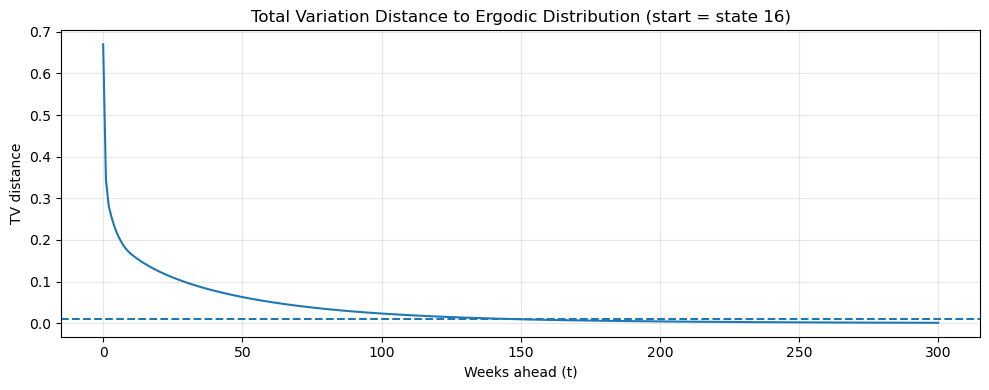


Expected WEI now (h=0): 2.170610932475884
Expected WEI in 2 years (h=104): 2.053366764940496
Long-run expected WEI (ergodic): 1.9647972224118098


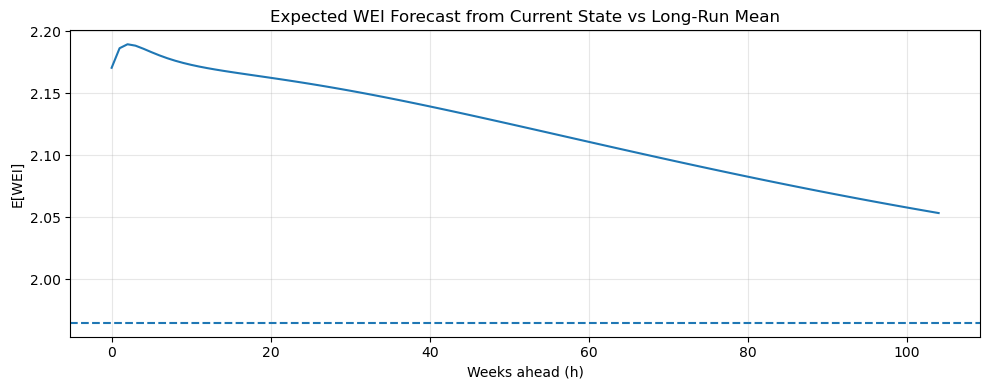


GDP growth part: I need a weekly GDP growth series (pd.Series) indexed by date.
Once you have it as `gdp_growth`, uncomment the block above to compute gdp_state_means and forecasts.


In [30]:
# =========================
# Problem 13: Persistence, Mixing, Long-Run Forecasts
# =========================
# Requires you already created:
#   df_states     : DataFrame with columns ["WEI","state"] indexed by date
#   P_df          : Markov transition matrix DataFrame (KxK)
#   state_means   : Series mapping state -> mean WEI in that state (Problem 5)
#   pi_df + class1 (from Problem 8) OR we recompute pi here
#
# Outputs:
#   - Expected duration (persistence) for each state
#   - Total variation distance path from current state to ergodic distribution
#   - Mixing time (first t where TV distance <= epsilon)
#   - t-step expected WEI forecasts + long-run expected WEI
#   - GDP growth forecast using state means + ergodic distribution (if GDP growth data is provided)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# 0) Setup
# -------------------------
P = P_df.to_numpy()
K = P.shape[0]

current_state = int(df_states["state"].iloc[-1])
print("Current state =", current_state)

# Main ergodic class from your Problem 7 output (everything except {25})
class1 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
          20, 21, 22, 23, 24, 26, 27, 28, 29]
idx_map = {s:i for i,s in enumerate(class1)}     # original -> sub-index
P1 = P[np.ix_(class1, class1)]                  # restrict to Class 1
m = len(class1)

# If current_state is outside Class 1 (rare), pick a fallback:
if current_state not in idx_map:
    print("Warning: current_state not in Class 1; using nearest state in Class 1 for mixing.")
    current_state = class1[-1]

s0 = idx_map[current_state]

# -------------------------
# 1) Persistence: expected duration in each state
# -------------------------
# If you're in state i, probability of staying is P_ii.
# Duration in i is geometric with mean: E[duration_i] = 1 / (1 - P_ii)
Pii = np.diag(P)
duration = np.where(1 - Pii > 0, 1 / (1 - Pii), np.inf)

duration_df = pd.DataFrame({"state": np.arange(K), "P_ii": Pii, "E_duration_weeks": duration})
print("\nExpected duration (weeks) by state (first 10):")
display(duration_df.head(10))

print("\nExpected duration in CURRENT state:", float(duration_df.loc[current_state, "E_duration_weeks"]), "weeks")

# -------------------------
# 2) Ergodic distribution on Class 1 (recompute safely)
# -------------------------
# Stationary distribution pi solves pi = pi P1 (left eigenvector at eigenvalue 1)
eigvals, eigvecs = np.linalg.eig(P1.T)
idx = np.argmin(np.abs(eigvals - 1))
pi = np.real(eigvecs[:, idx])
pi = pi / pi.sum()
pi = np.maximum(pi, 0)
pi = pi / pi.sum()

# Put in a dataframe
pi_df = pd.DataFrame({"state": class1, "pi": pi}).sort_values("state").reset_index(drop=True)
print("\nCheck sum(pi) =", pi_df["pi"].sum())

# -------------------------
# 3) Mixing via Total Variation distance from current state
# -------------------------
# Start dist: delta_{s0}
# After t steps: mu_t = delta_{s0} P1^t
# Total variation distance: TV(mu_t, pi) = 0.5 * sum_i |mu_t(i) - pi(i)|
def tv_distance(mu, nu):
    return 0.5 * np.sum(np.abs(mu - nu))

Tmax = 300          # how far to check mixing (weeks)
epsilon = 0.01      # mixing threshold (you can change to 0.05, 0.02, etc.)

mu = np.zeros(m)
mu[s0] = 1.0

tv_list = []
for t in range(Tmax + 1):
    tv_list.append(tv_distance(mu, pi))
    mu = mu @ P1  # advance distribution

tv_series = pd.Series(tv_list, name="TV_distance")

# Mixing time = first t where TV <= epsilon
mix_time = next((t for t, v in enumerate(tv_list) if v <= epsilon), None)
print(f"\nMixing time (TV <= {epsilon}):", mix_time, "weeks" if mix_time is not None else "Not reached within Tmax")

# Plot TV distance over time
plt.figure(figsize=(10,4))
plt.plot(tv_series.index, tv_series.values)
plt.axhline(epsilon, linestyle="--")
plt.title(f"Total Variation Distance to Ergodic Distribution (start = state {current_state})")
plt.xlabel("Weeks ahead (t)")
plt.ylabel("TV distance")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------
# 4) Forecasting expected WEI using state means
# -------------------------
# One-step/t-step ahead expected WEI:
#   E[WEI_{t+h} | s_t = s0] = (mu_h dot mean_WEI_by_state)
# Long-run expected WEI:
#   E_longrun[WEI] = (pi dot mean_WEI_by_state)

# Align WEI means to Class 1 order
mean_wei = state_means.reindex(class1).to_numpy()

# Build expected WEI path for horizons 0..H
H = 104  # 2 years
mu = np.zeros(m)
mu[s0] = 1.0

E_wei = []
for h in range(H + 1):
    E_wei.append(float(mu @ mean_wei))
    mu = mu @ P1

E_wei = pd.Series(E_wei, index=np.arange(H + 1), name="E_WEI_h")

E_wei_longrun = float(pi @ mean_wei)

print("\nExpected WEI now (h=0):", E_wei.iloc[0])
print("Expected WEI in 2 years (h=104):", E_wei.iloc[-1])
print("Long-run expected WEI (ergodic):", E_wei_longrun)

plt.figure(figsize=(10,4))
plt.plot(E_wei.index, E_wei.values)
plt.axhline(E_wei_longrun, linestyle="--")
plt.title("Expected WEI Forecast from Current State vs Long-Run Mean")
plt.xlabel("Weeks ahead (h)")
plt.ylabel("E[WEI]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------
# 5) GDP Growth Forecast using state means + ergodic distribution
# -------------------------
# You need a weekly GDP growth series aligned by date.
#
# Preferred workflow:
#   (a) create/bring in a weekly series 'gdp_growth' indexed by date (same weekly index)
#   (b) merge with df_states to get the WEI-state each week
#   (c) compute GDP growth mean within each WEI state: gdp_state_means[state]
#   (d) forecast:
#         short-run: E[g_{t+h}] = mu_h dot gdp_state_means (restricted to Class 1)
#         long-run : E[g] = pi dot gdp_state_means
#
# If you ALREADY have gdp_state_means, set it here and skip (a)-(c).

gdp_state_means = None  # <-- if you already computed it, replace None with your Series

# Example construction (uncomment once you have gdp_growth as a Series):
# gdp_growth = ...  # pd.Series indexed by date, weekly frequency, values = growth rate
# tmp = df_states[["state"]].join(gdp_growth.rename("gdp_growth"), how="inner").dropna()
# gdp_state_means = tmp.groupby("state")["gdp_growth"].mean()

if gdp_state_means is not None:
    gdp_mean = gdp_state_means.reindex(class1).to_numpy()

    # Forecast expected GDP growth path
    mu = np.zeros(m)
    mu[s0] = 1.0
    E_g = []
    for h in range(H + 1):
        E_g.append(float(mu @ gdp_mean))
        mu = mu @ P1
    E_g = pd.Series(E_g, index=np.arange(H + 1), name="E_gdp_growth_h")

    E_g_longrun = float(pi @ gdp_mean)

    print("\nGDP growth forecasts (using WEI-state means):")
    print("Expected GDP growth now (h=0):", E_g.iloc[0])
    print("Expected GDP growth in 2 years (h=104):", E_g.iloc[-1])
    print("Long-run expected GDP growth (ergodic):", E_g_longrun)

    plt.figure(figsize=(10,4))
    plt.plot(E_g.index, E_g.values)
    plt.axhline(E_g_longrun, linestyle="--")
    plt.title("Expected GDP Growth Forecast vs Long-Run Mean (via WEI states)")
    plt.xlabel("Weeks ahead (h)")
    plt.ylabel("E[GDP growth]")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\nGDP growth part: I need a weekly GDP growth series (pd.Series) indexed by date.")
    print("Once you have it as `gdp_growth`, uncomment the block above to compute gdp_state_means and forecasts.")


Starting from the current state $s_0=16$, I quantified persistence using the self-transition probability $P_{ii}$: since remaining in state $i$ each week occurs with probability $P_{ii}$, the run length in state $i$ is geometric with mean $\mathbb{E}[D_i]=1/(1-P_{ii})$. For the current state, this gives $\mathbb{E}[D_{16}]\approx 3.07$ weeks, meaning the chain is expected to stay in today’s state for about three weeks before transitioning.

To measure mixing, I computed the ergodic distribution $\pi$ on the main communicating class (the class containing almost all states) and verified it is a valid distribution with $\sum_i \pi_i \approx 1$. Letting $\mu_t=\delta_{s_0}P^t$ denote the $t$-step-ahead distribution starting from the current state, I measured convergence using total variation distance $\mathrm{TV}(\mu_t,\pi)=\tfrac{1}{2}\sum_i|\mu_t(i)-\pi(i)|$. Using the threshold $\mathrm{TV}(\mu_t,\pi)\le 0.01$, the estimated mixing time is $t_{\text{mix}}\approx 147$ weeks (about $2.8$ years), consistent with the slow decay shown in the TV-distance plot.

For forecasting, I used the state-dependent WEI means $\bar{y}_i$ and computed the $h$-step expected WEI as $\mathbb{E}[\mathrm{WEI}_{t+h}\mid s_t=s_0]=\mu_h\cdot \bar{y}$. The expected WEI starts at $\mathbb{E}[\mathrm{WEI}_t]\approx 2.1706$, declines slightly over the horizon to $\mathbb{E}[\mathrm{WEI}_{t+104}]\approx 2.0534$, and converges toward the long-run mean implied by the ergodic distribution, $\mathbb{E}_{\pi}[\mathrm{WEI}]=\pi\cdot \bar{y}\approx 1.9648$. This pattern indicates that, because the current state is somewhat above the long-run average, the forecast mean drifts downward toward the ergodic mean as $h$ increases.

The GDP-growth portion requires a weekly GDP growth series $g_t$ aligned to the same weekly date index; once available, the analogous forecast is $\mathbb{E}[g_{t+h}\mid s_t=s_0]=\mu_h\cdot \bar{g}$ with long-run mean $\mathbb{E}_{\pi}[g]=\pi\cdot \bar{g}$, where $\bar{g}_i=\mathbb{E}[g_t\mid s_t=i]$ is the state-dependent mean GDP growth.

The total-variation plot shows that the distribution of future states starting from $s_0=16$ gradually converges to the ergodic distribution: $\mathrm{TV}(\mu_t,\pi)$ falls steadily and crosses the $0.01$ threshold at about $t\approx147$ weeks, indicating relatively slow mixing. The expected-WEI forecast plot shows mean reversion: $\mathbb{E}[\mathrm{WEI}_{t+h}\mid s_t=16]$ starts around $2.17$ and drifts downward toward the long-run ergodic mean (dashed line) near $1.96$ as the horizon increases.

